<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/02_deep_learning_foundations/16_model_checkpointing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model Checkpointing

Training deep learning models can take a long time. Sometimes the model performs best before the final epoch.

Model Checkpointing automatically saves the best model during training based on a chosen metric such as validation loss or validation accuracy.

This allows us to use the best-performing model instead of simply using the model from the last training epoch.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
X = np.array([
    [0,0],[0,1],[1,0],[1,1],
    [0,0],[0,1],[1,0],[1,1],
    [0,0],[0,1],[1,0],[1,1]
], dtype=float)

y = np.array([
    [0],[0],[0],[1],
    [0],[0],[0],[1],
    [0],[0],[0],[1]
], dtype=float)

In [3]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [4]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [5]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [6]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath="best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

In [7]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    callbacks=[checkpoint],
    verbose=1
)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5000 - loss: 0.6876
Epoch 1: val_loss improved from None to 0.71080, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.5000 - loss: 0.6876 - val_accuracy: 0.5000 - val_loss: 0.7108
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5000 - loss: 0.6847
Epoch 2: val_loss improved from 0.71080 to 0.70739, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.5000 - loss: 0.6847 - val_accuracy: 0.5000 - val_loss: 0.7074
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.5000 - loss: 0.6820
Epoch 3: val_loss improved from 0.70739 to 0.70434, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.5000 - loss: 0.6820 - val_accuracy: 0.5000 - val_loss: 0.7043


In [8]:
best_model = tf.keras.models.load_model("best_model.keras")

In [9]:
loss, accuracy = best_model.evaluate(X_val, y_val)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 1.0000 - loss: 0.4422
Validation Loss: 0.44223126769065857
Validation Accuracy: 1.0


In [10]:
predictions = best_model.predict(X_val)

predicted_classes = (predictions >= 0.5).astype(int)

print(predicted_classes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
[[0]
 [0]
 [0]
 [0]]


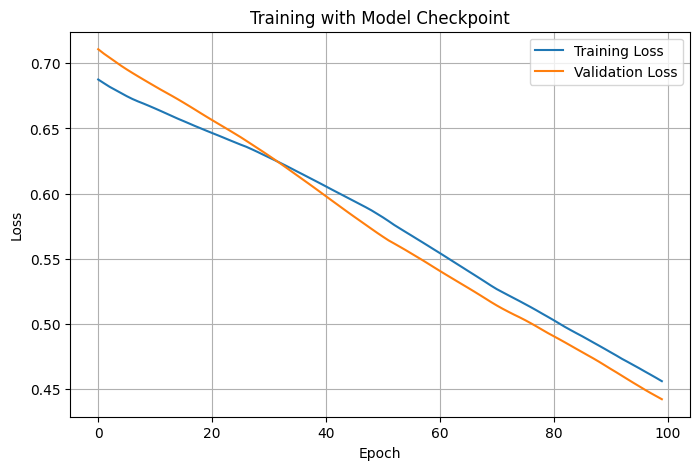

In [11]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training with Model Checkpoint")

plt.legend()
plt.grid()

plt.show()

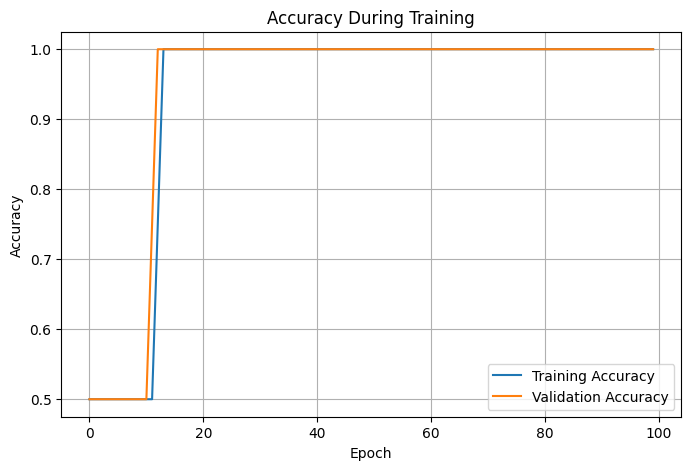

In [12]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy During Training")

plt.legend()
plt.grid()

plt.show()

In [13]:
import pandas as pd

results = pd.DataFrame({
    "Actual": y_val.flatten().astype(int),
    "Predicted": predicted_classes.flatten()
})

results

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0


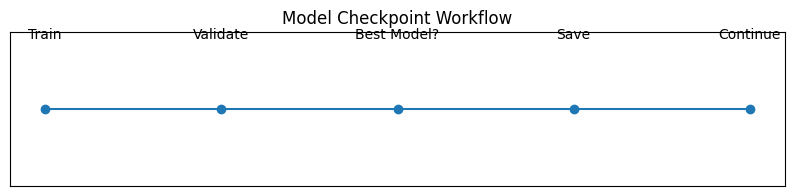

In [14]:
steps = [
    "Train",
    "Validate",
    "Best Model?",
    "Save",
    "Continue"
]

plt.figure(figsize=(10,2))

plt.plot(range(len(steps)), [1]*len(steps), marker="o")

for i, step in enumerate(steps):
    plt.text(i, 1.05, step, ha="center")

plt.xticks([])
plt.yticks([])

plt.title("Model Checkpoint Workflow")

plt.show()

In [15]:
summary = pd.DataFrame({
    "Feature": [
        "ModelCheckpoint",
        "save_best_only",
        "monitor",
        "filepath"
    ],
    "Purpose": [
        "Automatically saves models",
        "Saves only the best model",
        "Metric used for monitoring",
        "Location where the model is saved"
    ]
})

summary

,Feature,Purpose
0,ModelCheckpoint,Automatically saves models
1,save_best_only,Saves only the best model
2,monitor,Metric used for monitoring
3,filepath,Location where the model is saved
